2021-11-30 ~ 2023-12-01 까지 2년치 매일 30건씩

주차로 묶어서 시각화

# Figure 1(Difficulty)

In [1]:
visualization_target = input("INPUT 'visualization_target RUN_ID'(e.g., run_id_1): ")

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import os
from glob import glob

from setting_for_sdm.path_setting import path_list
from setting_for_sdm.date_setting import Date_Setting

import lib.annotation.tools.Result_Prep as rp

import lib.stats.stats as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from matplotlib import pyplot as plt
import matplotlib as mpl
import lib.visualization.plot_generator as PlotGen
import lib.visualization.font_setting as font_setting
mpl.rcParams['font.family'] = font_setting.init_font()




Helvetica /home/mghan/.fonts/Helvetica/Helvetica Oblique.ttf
Registered font name: Helvetica


In [3]:
viz_dir = f'{path_list["data_root_dir"]}/result/annotate_difficulty/{visualization_target}'
data_dir = f"{viz_dir}/data/csv"
option_dict = load_json(f"{viz_dir}/option.json")
output_dir = create_dir('./fig/')
date_range = 'Weekly'


# std_date = Date_Setting[option_dict['year_range']]['std_date']

In [4]:
path = f"{viz_dir}/{option_dict['operation_option']['llm_model']}"
file_list = os.listdir(path)

In [5]:
ver_list = sorted([y for y in [x for x in file_list if x.isdigit()] if (int(y)>=100000) & (int(y)<110000)])


In [6]:
ver_list

['100033',
 '100034',
 '100035',
 '100036',
 '100037',
 '100038',
 '100039',
 '100040',
 '100041',
 '100042',
 '100043',
 '100044',
 '100045',
 '100046',
 '100047']

In [7]:
r_p = rp.Result_Prep()

In [8]:
tot_calc = pd.DataFrame()
for listid in ver_list:
    df = r_p.make_one_file(listid, path)
    if isinstance(df, pd.core.frame.DataFrame):
        df = r_p.pp_df(df, 5)
        df = r_p.calc_rate_byweek(df)
        tot_calc = pd.concat([tot_calc, df], axis = 0)

    

In [9]:
tot_calc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 141 entries, 0 to 2
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rel_week  141 non-null    float64
 1   o_result  141 non-null    object 
 2   r_cnt     141 non-null    int64  
 3   tot_cnt   141 non-null    int64  
 4   rate      141 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 6.6+ KB


In [12]:
print(m_chk_cnt_0.loc[m_chk_cnt_0['o_result'].isna(), 'rate'])
print(m_chk_cnt_1.loc[m_chk_cnt_1['o_result'].isna(), 'rate'])
print(m_chk_cnt_2.loc[m_chk_cnt_2['o_result'].isna(), 'rate'])

Series([], Name: rate, dtype: float64)
Series([], Name: rate, dtype: float64)
Series([], Name: rate, dtype: float64)


In [13]:
m_chk_cnt_0.loc[:, 'o_result'] = '0'
m_chk_cnt_1.loc[:, 'o_result'] = '1'
m_chk_cnt_2.loc[:, 'o_result'] = '2'

In [14]:
x= m_chk_cnt_2['rel_week'].values
y= m_chk_cnt_2['rate'].values

st_chow_1year = st.Stats(x, y, 2, 0.95, m_chk_cnt_2[m_chk_cnt_2['rel_week'] ==1].index.values[0])
F_stat_1, p_value_1 = st_chow_1year.chow_test()


In [26]:
def draw_complexity_regression(ax, x, y, st_chow_1year,
                               F_stat_1, p_value_1, title,
                               panel_label=''):

    split_idx = np.where(x < 0)[0][-1] + 1

    x1 = x[:split_idx]
    x2 = x[split_idx:]

    # scatter
    ax.scatter(x, y, color='darkgray', alpha=0.7, s=10, marker='x')

    # Full model
    ax.plot(x, st_chow_1year.y_predict,
            linestyle="--", color="black",
            linewidth=1.5, label='Overall fit')

    # Before ChatGPT
    ax.plot(x1, st_chow_1year.y1_predict,
            linewidth=1.5, label='Before ChatGPT')

    ax.fill_between(
        x1,
        st_chow_1year.y1_predict - st_chow_1year.y1_conf_interval,
        st_chow_1year.y1_predict + st_chow_1year.y1_conf_interval,
        alpha=0.15
    )

    # After ChatGPT
    ax.plot(x2, st_chow_1year.y2_predict,
            linewidth=1.5, label='After ChatGPT')

    ax.fill_between(
        x2,
        st_chow_1year.y2_predict - st_chow_1year.y2_conf_interval,
        st_chow_1year.y2_predict + st_chow_1year.y2_conf_interval,
        alpha=0.15
    )

    # vertical line
    ax.axvline(x=0, color='#CC3333', linestyle='--', linewidth=1.2, zorder=5)

    # p-value text
    p_txt = '$p < 0.001$' if p_value_1 < 0.001 else f'$p = {p_value_1:.3f}$'
    p_color = '#CC3333' if p_value_1 < 0.05 else 'gray'

    # title
    ax.text(
        0.5, 1.08,
        f'Changes in {title}',
        transform=ax.transAxes,
        fontsize=font_setting.font_setting['title'],
        ha='center',
        va='bottom'
    )

    # p-value
    ax.text(
        0.5, 1.02,
        p_txt,
        ha='center',
        fontsize=font_setting.font_setting['p-value'],
        color=p_color,
        transform=ax.transAxes
    )

    # panel label
    if panel_label:
        ax.text(
            -0.08, 1.08,
            panel_label,
            transform=ax.transAxes,
            fontsize=font_setting.font_setting['panel'],
            fontweight='bold',
            va='bottom',
            ha='left'
        )

    # axis labels
    ax.set_xlabel("Week relative to ChatGPT release", fontsize=font_setting.font_setting['label'])
    ax.set_ylabel("Percentage(%)", fontsize=font_setting.font_setting['label'])

    # ticks
    ax.tick_params(axis='both', labelsize=font_setting.font_setting['tick'])

    # spine
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # grid
    ax.yaxis.grid(True, linestyle=':', linewidth=0.5,
                  color='gray', alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

    # legend
    ax.legend(fontsize=font_setting.font_setting['legend'], frameon=False)

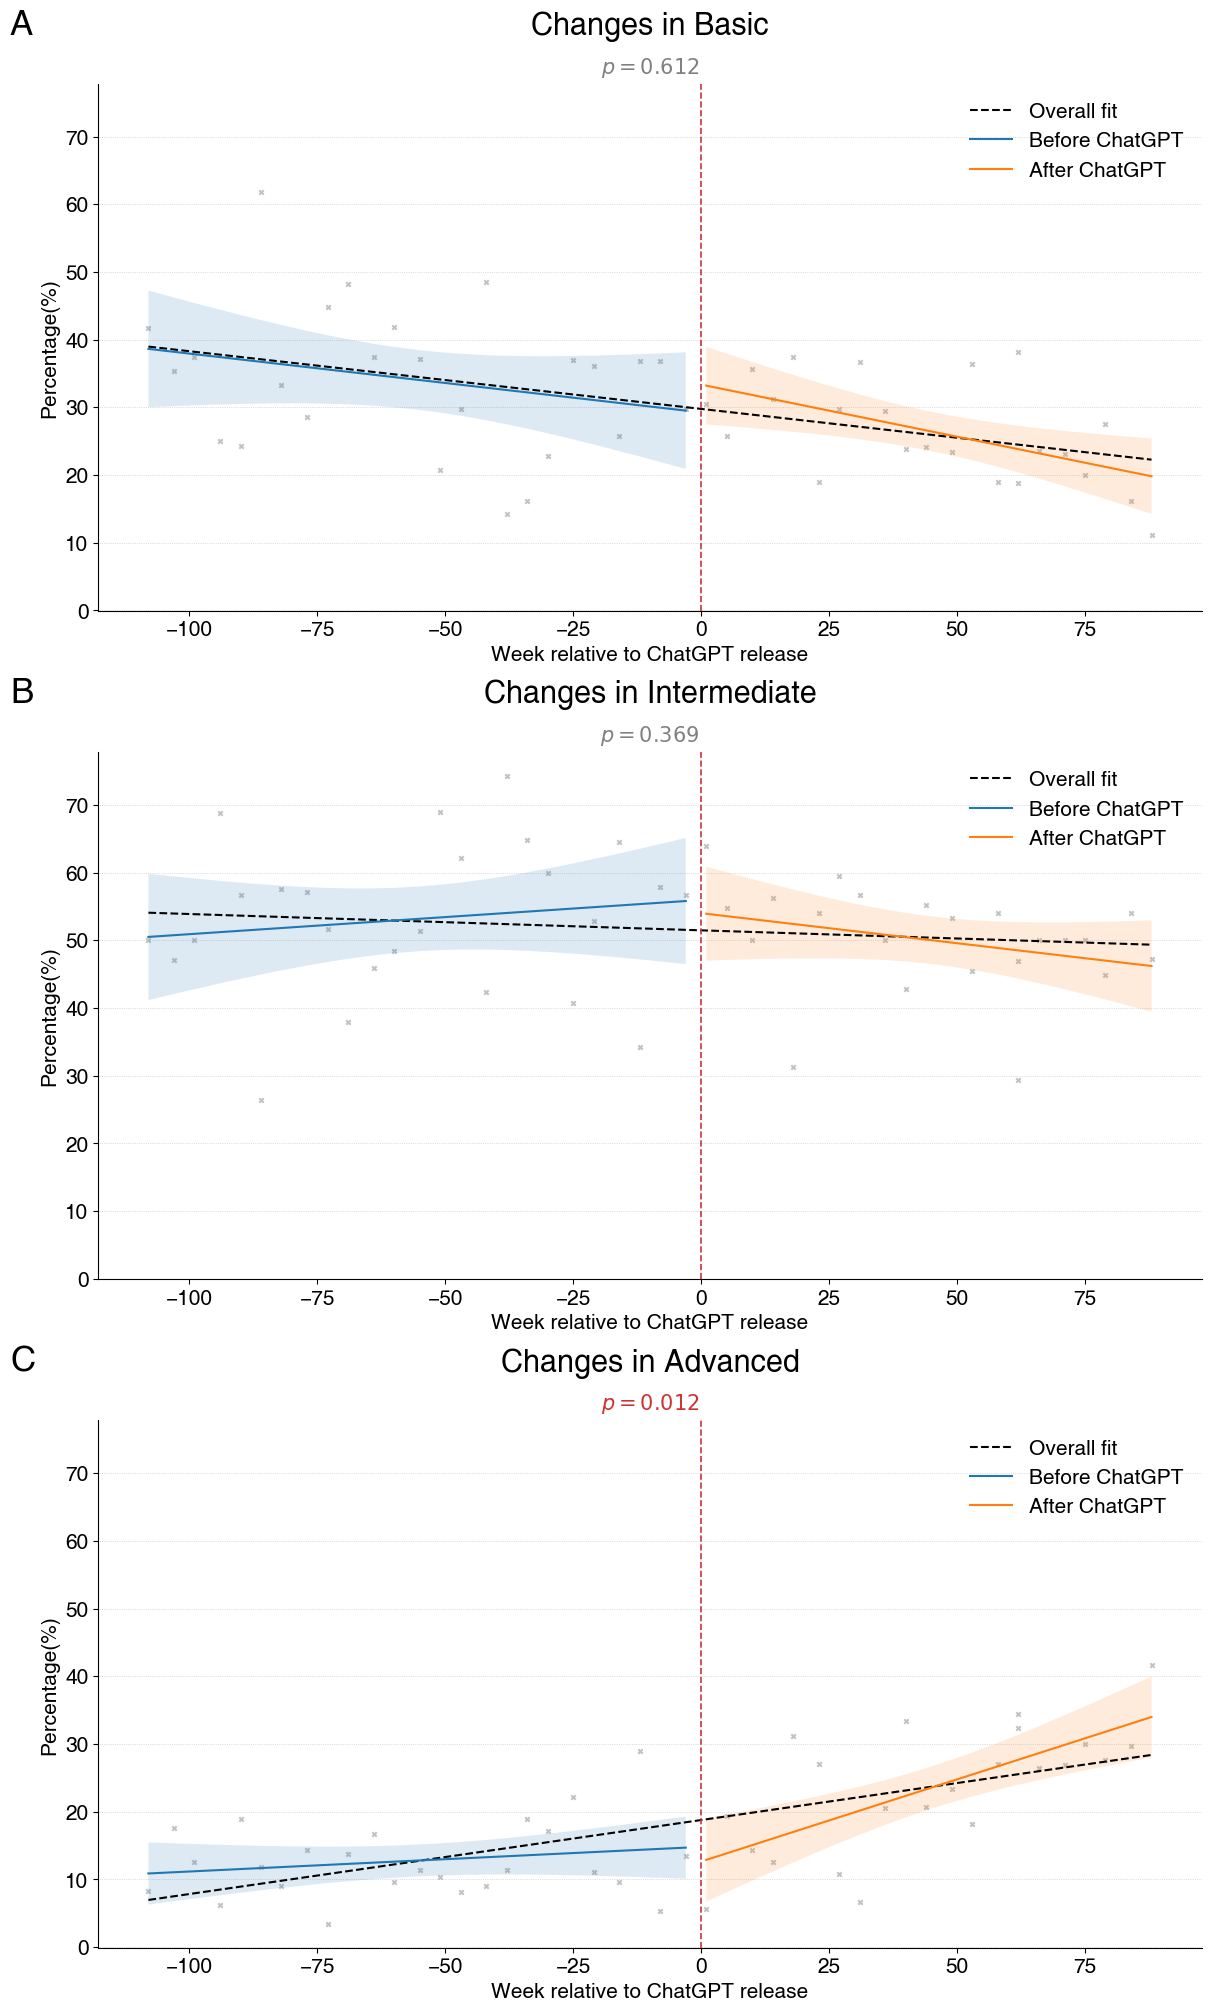

In [28]:
fig, ax = plt.subplots(3, 1, figsize=(12,20), constrained_layout=True, sharey=True)
label_dict = {'A' : 'Basic', 'B' : 'Intermediate', 'C':'Advanced'}

for i, (label, title) in enumerate(label_dict.items()):
    chk_cnt = tot_calc[tot_calc['o_result'] == str(i)].reset_index(drop=True)
    x = chk_cnt['rel_week'].values
    y = chk_cnt['rate'].values

    st_chow = st.Stats(x, y, 2, 0.95, chk_cnt[chk_cnt['rel_week'] ==1].index.values[0])
    F_stat, p_value = st_chow.chow_test()
    draw_complexity_regression(
        ax[i],
        x,
        y,
        st_chow,
        F_stat,
        p_value,
        title=f"{title}",
        panel_label=f"{label}"
    )



plt.savefig(
    f"{output_dir}/{visualization_target}.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()